# Quickstart: Surface Albedo

Surface albedo testing with pyradtran.

In [1]:
# Import PyRadtran components
from pyradtran.interface import PyRadtranAccessor
from pyradtran.config import SimulationConfig, PathsConfig, SimulationDefaults
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

# Configure logging
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

# Define configuration programmatically
config = SimulationConfig(
    paths=PathsConfig(
        libradtran_bin=Path('/opt/libRadtran-2.0.6/bin/uvspec'),
        libradtran_data=Path('/opt/libRadtran-2.0.6/data'),
        atmosphere_profile=Path('/opt/libRadtran-2.0.6/data/atmmod/afglsw.dat'),
        solar_spectrum=Path('/opt/libRadtran-2.0.6/data/solar_flux/NewGuey2003.dat'),
        output_dir=Path('work')
    ),
    simulation_defaults=SimulationDefaults(
        rte_solver='disort',
        wavelength_nm=[400, 700],
        integrate_wavelength=True,
        output_columns=['zout', 'lambda', 'eup', 'albedo'], # 'eup' is upwelling irradiance
        output_altitudes_km=[0.0],
    )
)

N_timesteps = 20
albedo_values = np.linspace(0.1, 0.9, N_timesteps)

# Create input dataset
ds = xr.Dataset(
    coords={
        'time': [pd.to_datetime('2025-04-04T08:00:00')], # this is 
        'latitude': ('time', [51.34]),
        'longitude': ('time', [12.37]),
        'altitude' : ('altitude', np.arange(0, 100, 1)),
    },
    data_vars={
        'albedo': ('albedo_dim', albedo_values),
    }
)

# Run simulation
print("Running simulation...")
ds_sim = ds.pyradtran.run(
    config=config,
    return_dataset=True,
    save_to_file=False,
    albedo_var='albedo' # Map dataset variable 'albedo' to LibRadtran parameter
)

print("\nSimulation complete!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset shape: {ds_sim.dims}")

Running simulation...


Running simulations: 100%|██████████| 20/20 [00:02<00:00,  7.55sim/s, Success=20, Total=20]


Simulation complete!
Dataset variables: ['zout', 'lambda', 'eup', 'albedo']
Dataset coordinates: ['albedo_dim', 'time', 'altitude']
Dataset shape: FrozenMappingWarningOnValuesAccess({'albedo_dim': 20, 'time': 1, 'altitude': 100})


In [2]:
ds_sim

<xarray.Dataset> Size: 65kB
Dimensions:     (albedo_dim: 20, time: 1, altitude: 100)
Coordinates:
  * albedo_dim  (albedo_dim) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * time        (time) datetime64[ns] 8B 2025-04-04T08:00:00
  * altitude    (altitude) float64 800B 0.0 1.0 2.0 3.0 ... 96.0 97.0 98.0 99.0
Data variables:
    zout        (altitude, albedo_dim, time) float64 16kB 0.0 0.0 ... 99.0 99.0
    lambda      (altitude, albedo_dim, time) float64 16kB 400.0 400.0 ... 400.0
    eup         (altitude, albedo_dim, time) float64 16kB 2.226e+04 ... 2.155...
    albedo      (altitude, albedo_dim, time) float64 16kB 0.1 0.1421 ... 0.8227
Attributes:
    point_id:             20250404_080000_51.34_12.37_0
    time:                 2025-04-04T08:00:00
    latitude:             51.34
    longitude:            12.37
    albedo:               0.1
    surface_temperature:  None
    altitude:             None
    generated_by:         pyradtran
    pyradtran_version:    unified_system
    generation_date:      2025-12-13T12:01:27.186635

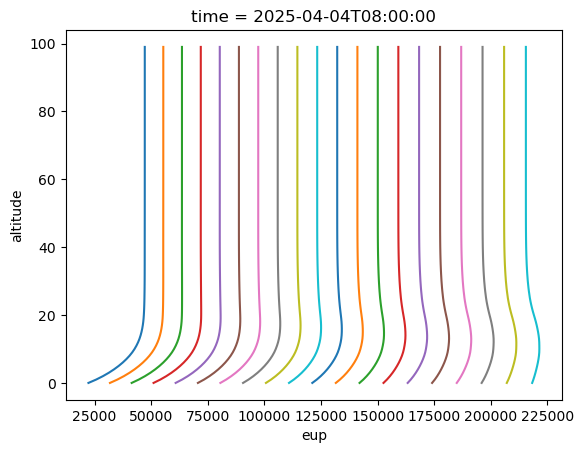

In [6]:
ds_sim.eup.squeeze().plot(hue='albedo_dim', y='altitude', add_legend=False)
plt.show()

## Results

Comparison of simulated radiation with different albedo configurations.

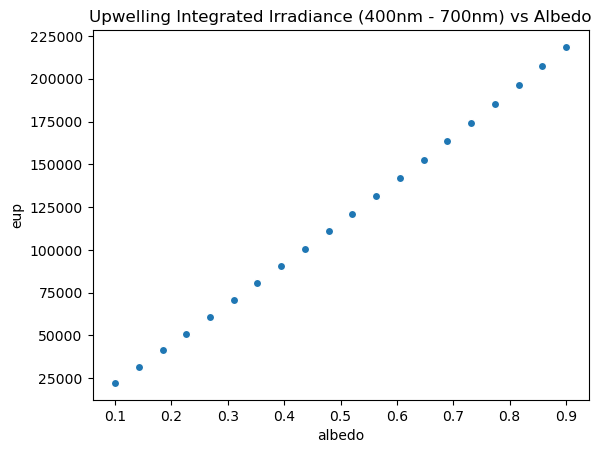

In [ ]:
ds_sim.sel(altitude=0).plot.scatter(
    x = 'albedo',
    y = 'eup'
)
plt.title('Upwelling Integrated Irradiance (400nm - 700nm) vs Albedo')
plt.show()